<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
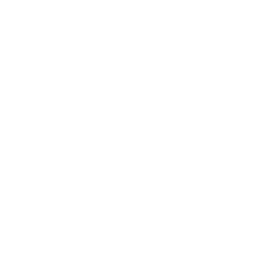
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Sjukhusavdelningars resursutnyttjande — horisontellt stapeldiagram</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Hälso- och sjukvård / Sjukhusdrift &nbsp;|&nbsp; Mars 2026</p>
</div>
</div>
</div>

## Sammanfattning

Det här exemplet använder horisontella stapeldiagram med **PROC GCHART** (HBAR) för att profilera personaltimmar över sex kliniska avdelningar för Q1 2026. En syntetisk personalloggbok med **90 skiftposter** (15 per avdelning) driver tre vyer: ett rangordnat stapeldiagram över totala timmar, genomsnittlig skiftlängd per avdelning, samt grupperade HBAR-diagram som delar upp varje avdelning efter resurskategori och efter skift. `SUMVAR=` ackumulerar faktiska arbetstimmar istället för att räkna poster, `TYPE=SUM`/`TYPE=MEAN` växlar responsstatistiken, `DESCENDING` rangordnar avdelningarna, och `GROUP=` ritar intilliggande grupperade staplar för en andra dimension.

Resultatet stödjer den kvartalsvisa granskningen av driftseffektivitet: det visar vilka avdelningar som förbrukar mest arbetskraft, vilka som kör de längsta skiften, och hur dag-/kväll-/nattbemanningsmönstret skiljer sig mellan enheter med kontinuerlig vårdintensitet och dagorienterade tjänster.

## Datakällor

| Källa | Beskrivning | Poster |
|--------|-------------|--------|
| WORK.STAFFING_LOG | Individuella skiftposter med arbetade timmar | 90 |
| WORK.DEPT_SUMMARY | Avdelningssummor och genomsnittlig skiftlängd | 6 |

---

In [1]:
/* --------------------------------------------------------
   Generera en syntetisk personalloggbok för ett sjukhus.
   Q1 2026: 6 kliniska avdelningar, 4 resurskategorier,
   3 skift. Dimensionerad till 15 skiftposter per avdelning
   (90 totalt) så att hela avdelningslistan förblir synlig.
   -------------------------------------------------------- */
data work.staffing_log;
    CALL streaminit(20260601);
    LÄNGD department $24 resource_type $24 shift $10;

    /* resurskategori-mix (omvårdnadstung klinisk bemanning) */
    FÄLT resw[4] _temporary_ (0.50 0.20 0.20 0.10);

    /* baslinje-skiftmix, förskjuten mot natt för dygnet-runt-enheter */
    FÄLT shfw[3] _temporary_ (0.45 0.30 0.25);
    FÄLT nightlift[6] _temporary_
        (0.18 0.00 0.22 -0.05 -0.05 0.05);

    GÖR di = 1 TILL 6;
        OM di = 1 SÅ department = "Akutmottagning";
        ANNARS OM di = 2 SÅ department = "Kirurgi";
        ANNARS OM di = 3 SÅ department = "Intensivvård";
        ANNARS OM di = 4 SÅ department = "Pediatrik";
        ANNARS OM di = 5 SÅ department = "Onkologi";
        ANNARS department = "Förlossning";

        GÖR rec = 1 TILL 15;

            /* resurstyp via viktat urval */
            u = rand("uniform"); cum = 0;
            GÖR r = 1 TILL 4;
                cum + resw[r];
                OM u <= cum SÅ GÖR;
                    OM r = 1 SÅ resource_type = "Omvårdnad";
                    ANNARS OM r = 2 SÅ resource_type = "Läkare";
                    ANNARS OM r = 3 SÅ resource_type = "Övrig vårdpersonal";
                    ANNARS resource_type = "Stödpersonal";
                    LÄMNA;
                SLUT;
            SLUT;

            /* skift via avdelningsspecifik nattförskjutning */
            w1 = shfw[1] - nightlift[di] / 2;
            w2 = shfw[2] - nightlift[di] / 2;
            u = rand("uniform");
            OM u <= w1 SÅ shift = "Dag";
            ANNARS OM u <= w1 + w2 SÅ shift = "Kväll";
            ANNARS shift = "Natt";

            /* timmar: läkare och kirurgi kör längre skift */
            base = 8;
            OM resource_type = "Läkare" SÅ base = base + 1.5;
            OM department = "Kirurgi"      SÅ base = base + 1.0;
            hours_worked = round(base + rand("normal", 0, 0.8), 0.25);
            OM hours_worked < 4 SÅ hours_worked = 4;

            UTDATA;
        SLUT;
    SLUT;
    BEHÅLL department resource_type shift hours_worked;
    ETIKETT department = "Avdelning" resource_type = "Resurstyp"
          shift = "Skift" hours_worked = "Arbetade timmar";
KÖR;


NOTE: DATA work.staffing_log


NOTE: Wrote work.staffing_log (90 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


In [2]:
/* --------------------------------------------------------
   Avdelningssummor och genomsnittlig skiftlängd,
   rangordnade efter totala arbetstimmar.
   -------------------------------------------------------- */
PROCEDUR SQL;
    CREATE TABLE work.dept_summary AS
    VÄLJ department,
           sum(hours_worked)  AS total_hours   format=8.2,
           count(*)           AS shift_count,
           mean(hours_worked) AS avg_shift_hrs  format=6.2
    FROM work.staffing_log
    GROUP EFTER department
    ORDER EFTER total_hours DESC;
QUIT;

PROCEDUR SKRIV data=work.dept_summary noobs ETIKETT;
    ETIKETT department     = "Avdelning"
          total_hours   = "Totala timmar"
          shift_count   = "Antal skift"
          avg_shift_hrs = "Genomsnittligt skift (tim)";
    TITEL "Avdelningens personalsammanfattning - Q1 2026";
KÖR;
TITEL;

                                     Avdelningens personalsammanfattning - Q1 2026                                      

     Avdelning  Totala timmar  Antal skift  Genomsnittligt skift (tim)
Kirurgi                136.25           15                        9.08
Intensivvård           128.50           15                        8.57
Förlossning            127.75           15                        8.52
Pediatrik              124.75           15                        8.32
Onkologi               123.75           15                        8.25
Akutmottagning         119.25           15                        7.95




NOTE: PROC SQL 

NOTE: Table work.dept_summary created.
NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=work.dept_summary

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


---

                                               Arbetstimmar per avdelning                                               

                                                  The MEANS Procedure

                                    Analysis Variable : hours_worked Arbetade timmar

        Avdelning                 Sum           Mean          N Obs
        -----------------------------------------------------------
        Akutmottagning         119.25           7.95             15
        Förlossning            127.75           8.52             15
        Intensivvård           128.50           8.57             15
        Kirurgi                136.25           9.08             15
        Onkologi               123.75           8.25             15
        Pediatrik              124.75           8.32             15
        -----------------------------------------------------------

                                             Skiftfördelning per avdelning                                  


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_department_shift.spec.json
NOTE: PROC FREQ statement used.


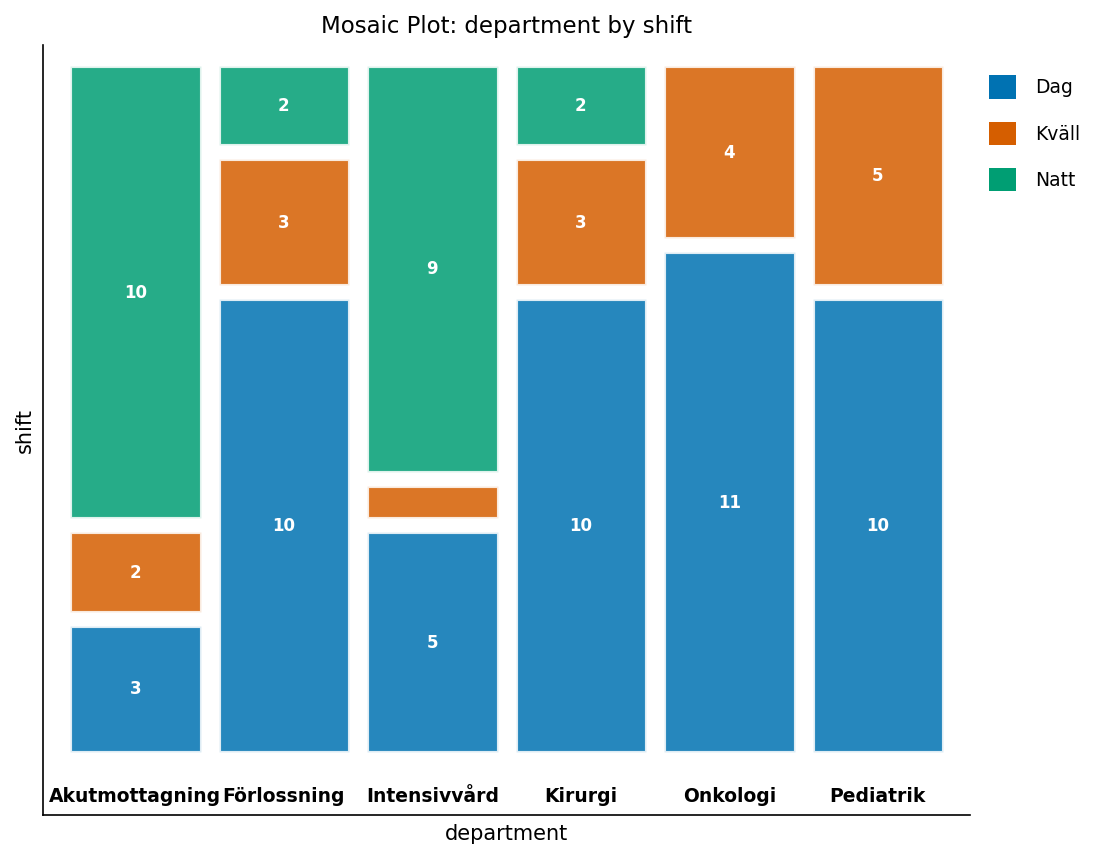

In [3]:
/* --------------------------------------------------------
   Baslinjetabeller: arbetstimmar per avdelning, och
   dag-/kväll-/nattfördelningen per avdelning.
   -------------------------------------------------------- */
PROCEDUR MEDELVÄRDEN data=work.staffing_log sum mean n maxdec=2;
    KLASS department;
    VARIABEL hours_worked;
    ETIKETT department = "Avdelning" hours_worked = "Arbetade timmar";
    TITEL "Arbetstimmar per avdelning";
KÖR;

PROCEDUR FREKVENSER data=work.staffing_log;
    TABLES department * shift / norow nocol nopercent;
    ETIKETT department = "Avdelning" shift = "Skift";
    TITEL "Skiftfördelning per avdelning";
KÖR;
TITEL;

---


NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


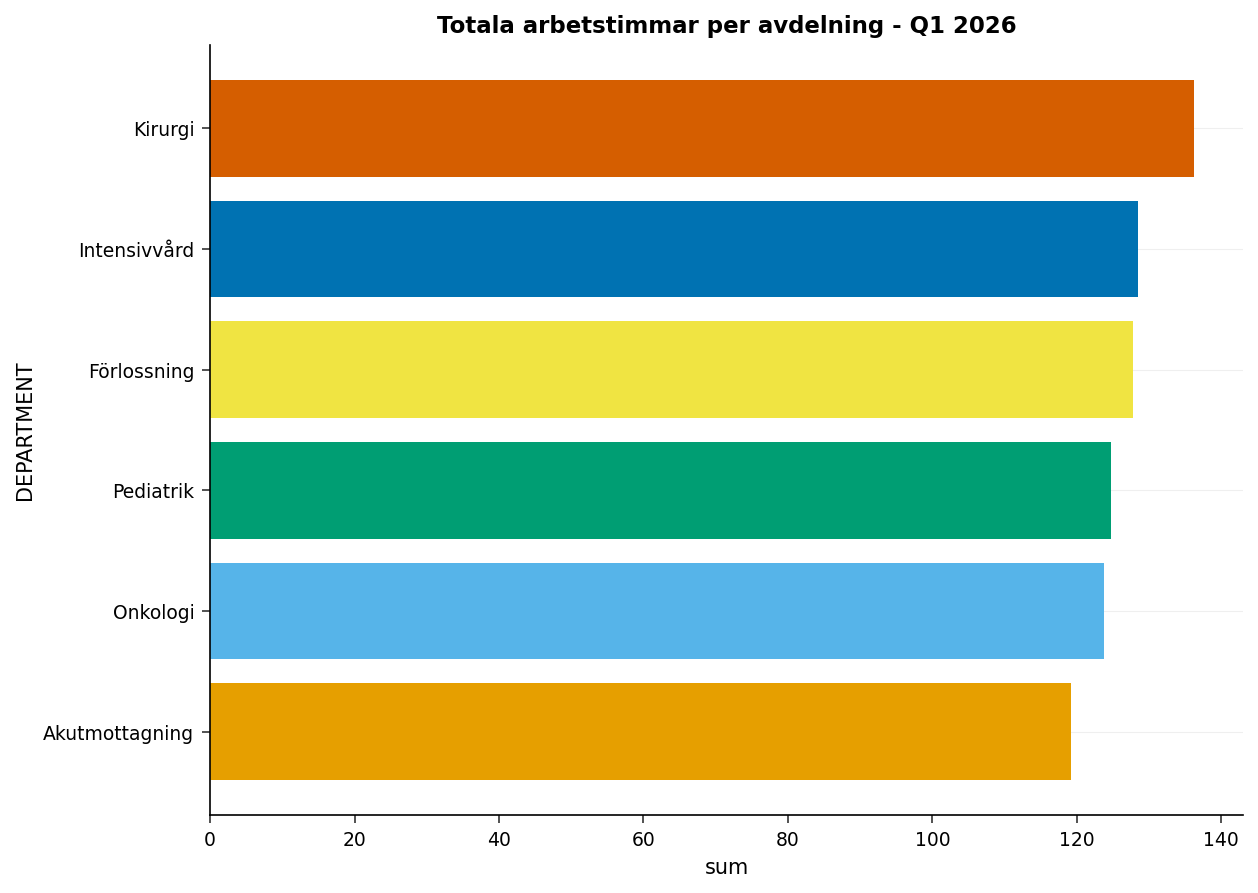

In [4]:
/* --------------------------------------------------------
   Översikts-HBAR: totala arbetstimmar per avdelning.
   SUMVAR= ackumulerar timmar; DESCENDING rangordnar staplarna.
   -------------------------------------------------------- */
PROCEDUR GCHART data=work.staffing_log;
    HBAR department / sumvar=hours_worked
                      type=sum
                      descending;
    TITEL "Totala arbetstimmar per avdelning - Q1 2026";
KÖR;
QUIT;
TITEL;

### Uppdelning av varje avdelning efter resurskategori

`GROUP=` ritar ett kluster av intilliggande horisontella staplar för varje avdelning, en stapel per resurskategori. Eftersom `SUMVAR=hours_worked` fortfarande gäller mäter varje stapel ackumulerade arbetstimmar istället för ett antal poster, så diagrammet visar hur omvårdnads-, läkar-, övrig vårdpersonal- och stödpersonaltimmar förhåller sig *inom* varje avdelning.

In [5]:
/* --------------------------------------------------------
   PATTERN-satser: samordnad 4-färgspalett,
   ett mönster per resurstyp-undergrupp
   -------------------------------------------------------- */
pattern1 value=solid color=cx2C5F8A;   /* Omvårdnad — mörkblå        */
pattern2 value=solid color=cx28A745;   /* Läkare — grön              */
pattern3 value=solid color=cxE8650A;   /* Övrig vårdpersonal — bärnstensfärgad */
pattern4 value=solid color=cx6C757D;   /* Stödpersonal — grå         */

                                      Avdelningens arbetstimmar per resurskategori                                      


Källa: Personalhanteringssystem | Rapportperiod: jan-mars 2026



NOTE: Option TITLE changed to Avdelningens arbetstimmar per resurskategori.
NOTE: Option FOOTNOTE changed to Källa: Personalhanteringssystem | Rapportperiod: jan-mars 2026.
NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


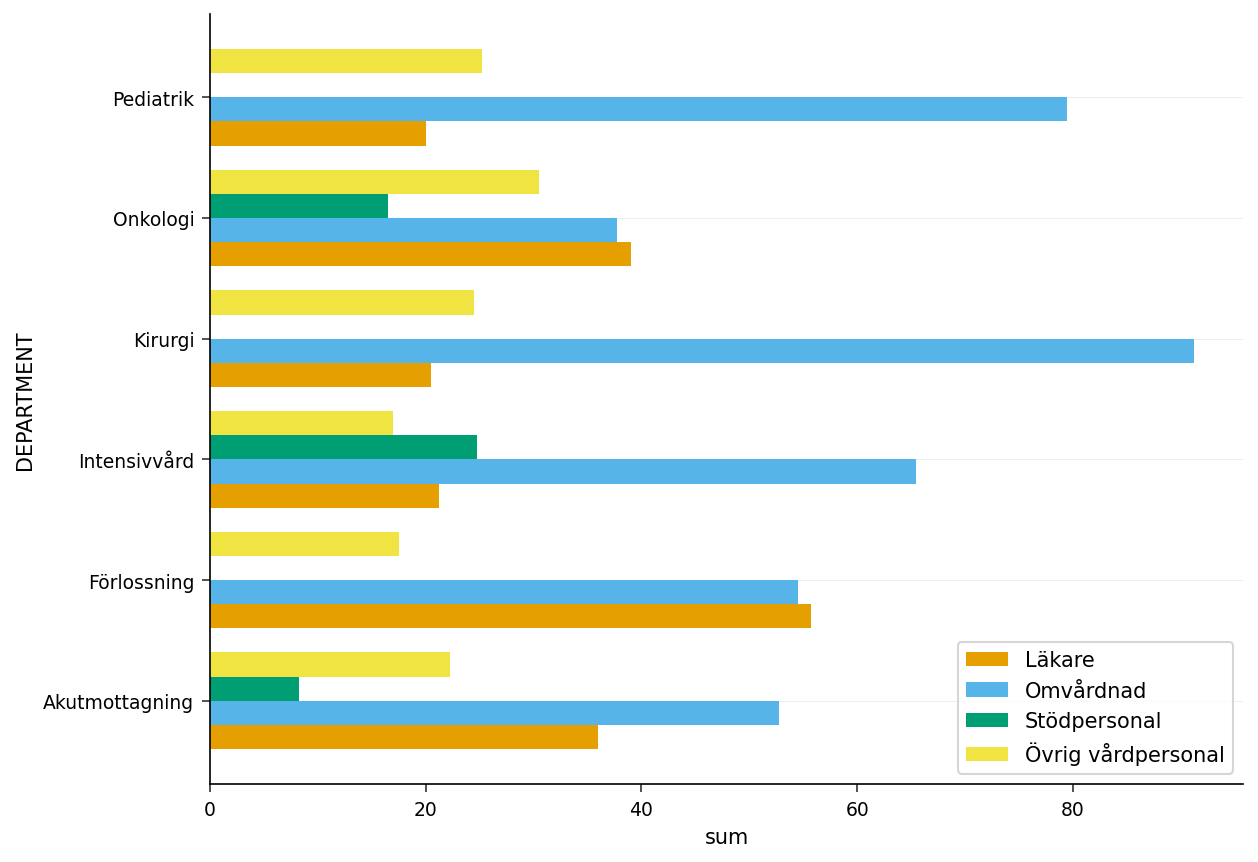

In [6]:
/* --------------------------------------------------------
   HBAR grupperad efter resurskategori (GROUP=).
   Varje avdelning blir ett kluster av staplar -- en per
   resurstyp -- mätt i ackumulerade arbetstimmar.
   -------------------------------------------------------- */
TITEL "Avdelningens arbetstimmar per resurskategori";
footnote justify=left
    "Källa: Personalhanteringssystem | Rapportperiod: jan-mars 2026";

PROCEDUR GCHART data=work.staffing_log;
    HBAR department / group=resource_type
                      sumvar=hours_worked
                      type=sum;
KÖR;
QUIT;

TITEL; footnote;

                                          Avdelningens arbetstimmar per skift                                           


Grupperade staplar separerar dag-, kväll- och nattbidrag per avdelning



NOTE: Option TITLE changed to Avdelningens arbetstimmar per skift.
NOTE: Option FOOTNOTE changed to Grupperade staplar separerar dag-, kväll- och nattbidrag per avdelning.
NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


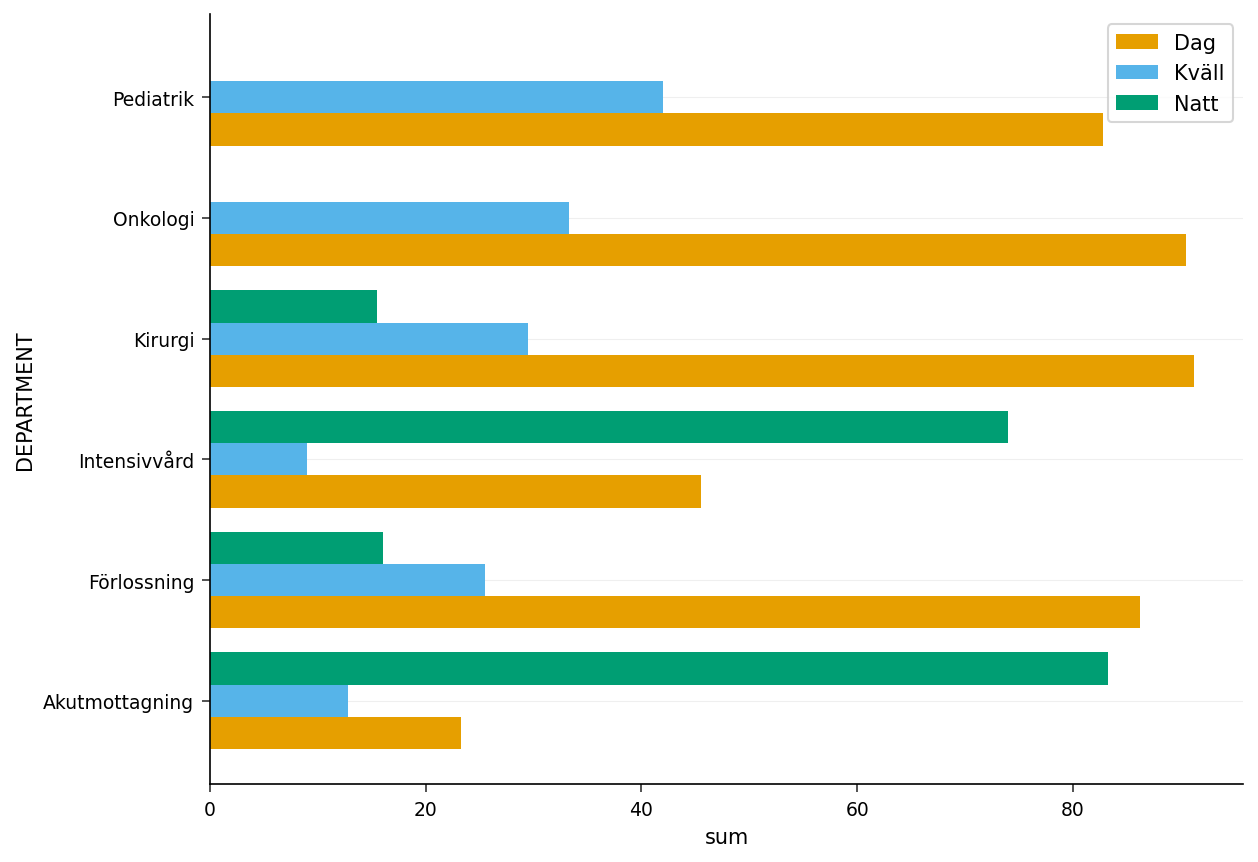

In [7]:
/* --------------------------------------------------------
   HBAR grupperad efter skift (GROUP=).
   Separerar dag-/kväll-/nattarbetstimmar inom varje
   avdelning -- lyfter fram enheterna med dygnet-runt-vård.
   -------------------------------------------------------- */
TITEL "Avdelningens arbetstimmar per skift";
footnote justify=left
    "Grupperade staplar separerar dag-, kväll- och nattbidrag per avdelning";

PROCEDUR GCHART data=work.staffing_log;
    HBAR department / group=shift
                      sumvar=hours_worked
                      type=sum;
KÖR;
QUIT;

TITEL; footnote;


NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


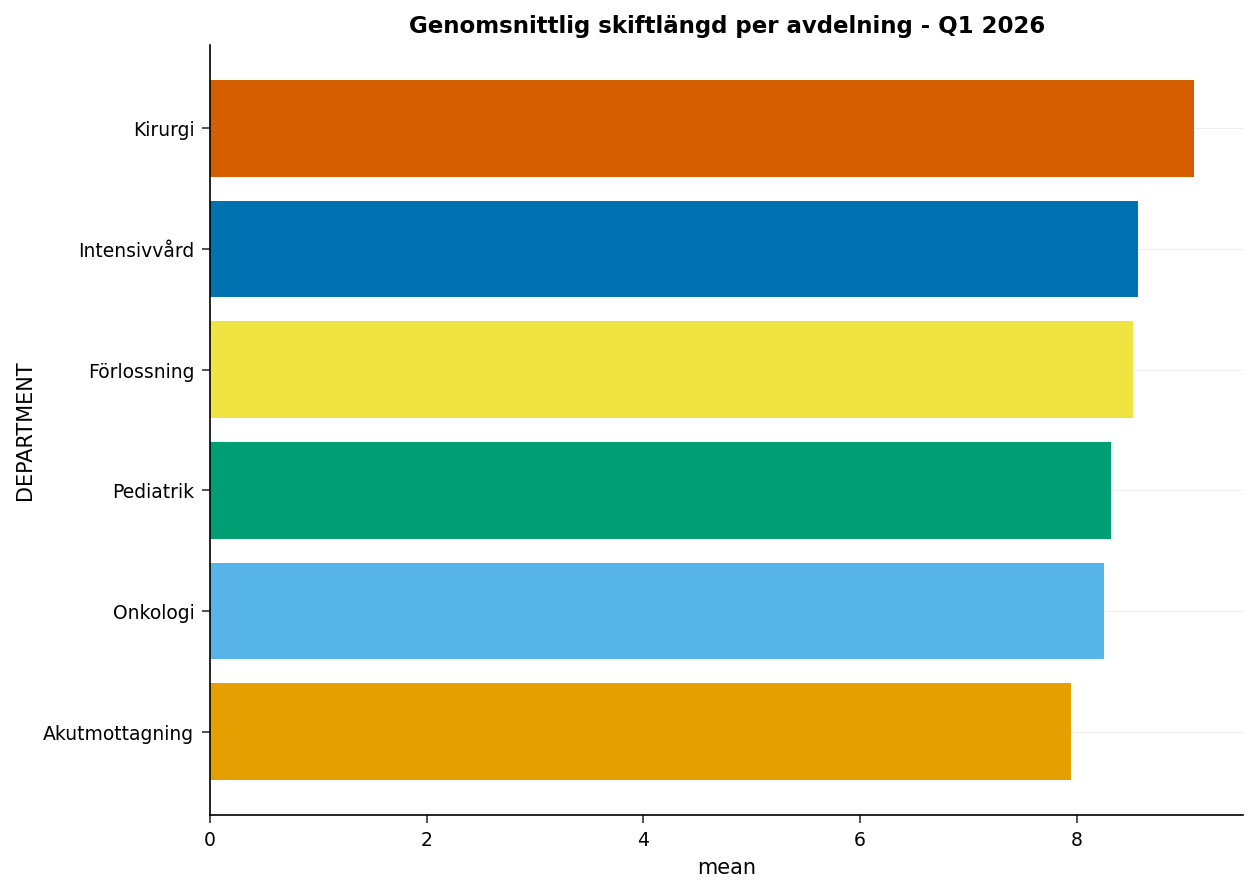

In [8]:
/* --------------------------------------------------------
   Genomsnittlig skiftlängd per avdelning (TYPE=MEAN).
   Visar om en avdelning kör långa skift eller många
   kortare, oberoende av total volym.
   -------------------------------------------------------- */
PROCEDUR GCHART data=work.staffing_log;
    HBAR department / sumvar=hours_worked
                      type=mean
                      descending;
    TITEL "Genomsnittlig skiftlängd per avdelning - Q1 2026";
KÖR;
QUIT;
TITEL;

---

### Tolkning

Över de 90 skiftposterna rör sig totala arbetstimmar inom ett smalt band från **119,25** (Akutmottagning) till **136,25** (Kirurgi), eftersom varje avdelning bär samma 15 skift under den här perioden — så rangordningen speglar **skiftlängd**, inte antal skift. Kirurgi toppar både diagrammet över totala timmar och diagrammet över genomsnittligt skift med **9,08 timmar** per skift, i linje med längre operationsfall och den läkartunga bemanning sådana fall kräver. Akutmottagning ligger lägst på timmar (genomsnitt **7,95**) trots att den är en av de mest välbesökta enheterna, eftersom dess arbete utförs i kortare skift med högre omsättning.

Det skiftgrupperade HBAR-diagrammet och mosaikpanelen berättar den driftsmässigt viktiga historien. **Akutmottagning och Intensivvård är nattdominerade** — 10 av 15 respektive 9 av 15 skift faller på natt — medan **Onkologi och Pediatrik inte har några nattskift alls** och koncentrerar sig på dagtäckning (11 respektive 10 dagskift). Den uppdelningen speglar verklig sjukhusbemanning: enheter med kontinuerlig vårdintensitet går dygnet runt, medan onkologisk infusionsbehandling och allmän pediatrik är dagorienterade tjänster. Resurskategoripanelen bekräftar en **omvårdnadsledd mix** i varje avdelning, med läkar- och övrig vårdpersonal-timmar som de sekundära nivåerna.

Inför Q2-personalgranskningen är nattskiftskoncentrationen i Akutmottagning och Intensivvård den post som bör bevakas: det är där premietillägg och kostnader för hantering av trötthet ackumuleras, och där varje ändring av rotationen har störst budgetpåverkan.

---

In [9]:
/* --------------------------------------------------------
   Exportera avdelningssammanfattningen för
   personalplaneringssystemet.
   -------------------------------------------------------- */
PROCEDUR EXPORTERA data=work.dept_summary
    outfile="q1_dept_labor_summary.csv"
    dbms=csv replace;
KÖR;


NOTE: PROC EXPORT data=work.dept_summary outfile=q1_dept_labor_summary.csv

NOTE: Exported 6 rows to q1_dept_labor_summary.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Konfidentiellt
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Drivs av <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>